# 🧠 Salud Mental en Adolescentes y Uso de Redes Sociales
## Clasificación Supervisada: Bajo / Medio / Alto
**Universidad Galileo — Manejo de Datos para la IA**

## 1. Instalación e Importación de Librerías

In [23]:
# Instalar kaggle si no está disponible
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Descarga del Dataset desde Kaggle

Las credenciales se cargan automáticamente desde el archivo `.env` del proyecto.

In [24]:
import os
import json
from dotenv import load_dotenv

# Cargar credenciales desde .env
load_dotenv()

kaggle_username = os.getenv('KAGGLE_USERNAME')
kaggle_key = os.getenv('KAGGLE_KEY')

if not kaggle_username or not kaggle_key:
    raise ValueError('❌ Falta KAGGLE_USERNAME o KAGGLE_KEY en el archivo .env')

# Crear el archivo kaggle.json que necesita la librería
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')
with open(kaggle_json_path, 'w') as f:
    json.dump({'username': kaggle_username, 'key': kaggle_key}, f)

os.chmod(kaggle_json_path, 0o600)

print(f'✅ Credenciales configuradas para: {kaggle_username}')

✅ Credenciales configuradas para: kevinarguetagalileo


In [25]:
# Descargar el dataset
!kaggle datasets download -d algozee/teenager-menthal-healy --unzip

# Ver qué archivos se descargaron
!ls -lh

Dataset URL: https://www.kaggle.com/datasets/algozee/teenager-menthal-healy
License(s): apache-2.0
100%|███████████████████████████████████████| 15.8k/15.8k [00:00<00:00, 156kB/s]
100%|███████████████████████████████████████| 15.8k/15.8k [00:00<00:00, 155kB/s]
total 1.5M
-rw-rw-r-- 1 kevin-osigu kevin-osigu  43K May 27 17:09 grafica_categorica_target.png
-rw-rw-r-- 1 kevin-osigu kevin-osigu  31K May 27 17:10 grafica_confusion.png
-rw-rw-r-- 1 kevin-osigu kevin-osigu 219K May 27 17:09 grafica_correlacion.png
-rw-rw-r-- 1 kevin-osigu kevin-osigu  74K May 27 17:09 grafica_distribucion_target.png
-rw-rw-r-- 1 kevin-osigu kevin-osigu  67K May 27 17:10 grafica_importancia.png
-rw-rw-r-- 1 kevin-osigu kevin-osigu 206K May 27 17:09 grafica_numericas.png
-rw-rw-r-- 1 kevin-osigu kevin-osigu  999 May 27 14:50 instructions.txt
-rw-rw-r-- 1 kevin-osigu kevin-osigu 117K May 27 14:50 Proyecto_instrucciones.pdf
-rw-rw-r-- 1 kevin-osigu kevin-osigu  166 May 27 16:00 requirements.txt
-rw-rw-r-- 1 kevin

## 3. Carga del Dataset

In [26]:
import glob

# Encontrar el archivo CSV automáticamente
csv_files = glob.glob('*.csv')
print('Archivos CSV encontrados:', csv_files)

# Cargar el primero que encuentre
df = pd.read_csv(csv_files[0])

print(f'\n✅ Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Archivos CSV encontrados: ['Teen_Mental_Health_Dataset.csv']

✅ Dataset cargado: 1200 filas x 13 columnas


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 4. Exploración Básica del Dataset (EDA)

In [27]:
print('=== INFORMACIÓN GENERAL ===')
df.info()

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)


In [28]:
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe(include='all')

=== ESTADÍSTICAS DESCRIPTIVAS ===


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.928333,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833
std,2.021947,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704
min,13.000000,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000
25%,14.000000,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000
50%,16.000000,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000
75%,18.000000,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000


In [29]:
print('=== COLUMNAS DEL DATASET ===')
for i, col in enumerate(df.columns):
    print(f'{i+1}. {col} — tipo: {df[col].dtype}')

=== COLUMNAS DEL DATASET ===
1. age — tipo: int64
2. gender — tipo: object
3. daily_social_media_hours — tipo: float64
4. platform_usage — tipo: object
5. sleep_hours — tipo: float64
6. screen_time_before_sleep — tipo: float64
7. academic_performance — tipo: float64
8. physical_activity — tipo: float64
9. social_interaction_level — tipo: object
10. stress_level — tipo: int64
11. anxiety_level — tipo: int64
12. addiction_level — tipo: int64
13. depression_label — tipo: int64


## 5. Limpieza de Datos

In [30]:
print('=== VALORES NULOS POR COLUMNA ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ No hay valores nulos')

print(f'\n=== FILAS DUPLICADAS: {df.duplicated().sum()} ===')

=== VALORES NULOS POR COLUMNA ===
✅ No hay valores nulos

=== FILAS DUPLICADAS: 0 ===


In [31]:
# Eliminar duplicados si los hay
df = df.drop_duplicates()

# Llenar nulos numéricos con la mediana
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Llenar nulos categóricos con la moda
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'✅ Dataset limpio: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Dataset limpio: 1200 filas x 13 columnas


## 6. Visualizaciones (EDA Gráfico)

> **IMPORTANTE:** Antes de correr esta sección, identificar cuál es la variable objetivo.
> Es la columna que indica el nivel de afectación (Bajo/Medio/Alto).
> Cámbiala en la celda siguiente.

In [32]:
# Crear variable objetivo compuesta: Riesgo de Salud Mental
# Promedio de stress_level, anxiety_level y addiction_level (escala 1-10)
df['mental_health_score'] = (df['stress_level'] + df['anxiety_level'] + df['addiction_level']) / 3

# Clasificar en Bajo / Medio / Alto con umbrales fijos
def clasificar_riesgo(score):
    if score <= 4:
        return 'Bajo'
    elif score <= 7:
        return 'Medio'
    else:
        return 'Alto'

df['mental_health_risk'] = df['mental_health_score'].apply(clasificar_riesgo)

TARGET_COLUMN = 'mental_health_risk'

print(f'✅ Variable objetivo creada: "{TARGET_COLUMN}"')
print(f'   Construida como promedio de: stress_level, anxiety_level, addiction_level')
print(f'   Umbrales: Bajo (≤4) | Medio (4-7] | Alto (>7)')
print(f'\nDistribución de clases:')
print(df[TARGET_COLUMN].value_counts())

✅ Variable objetivo creada: "mental_health_risk"
   Construida como promedio de: stress_level, anxiety_level, addiction_level
   Umbrales: Bajo (≤4) | Medio (4-7] | Alto (>7)

Distribución de clases:
mental_health_risk
Medio    731
Bajo     254
Alto     215
Name: count, dtype: int64


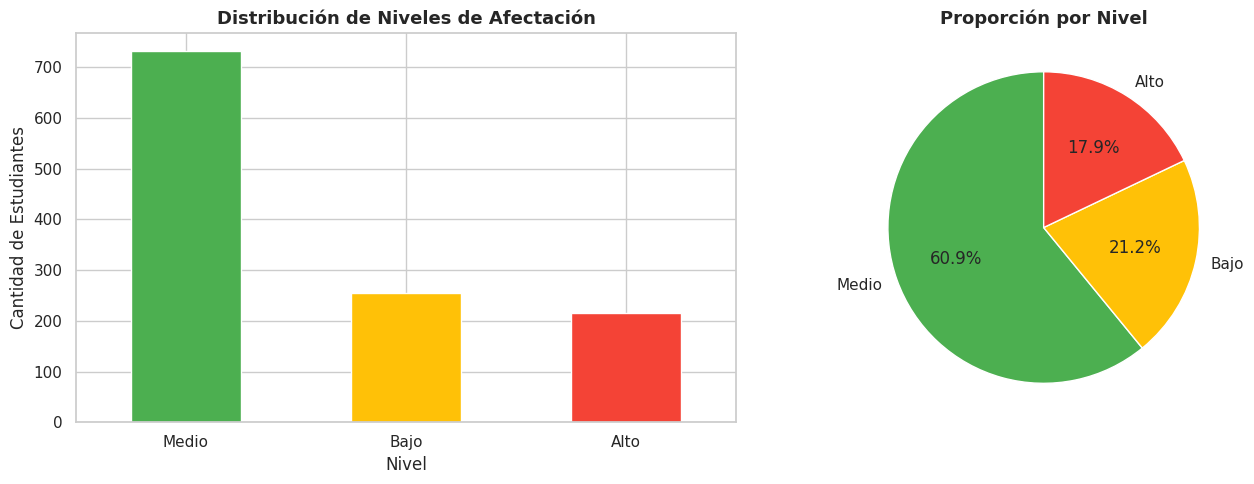

✅ Gráfica guardada


In [33]:
# Gráfica 1: Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conteo = df[TARGET_COLUMN].value_counts()
conteo.plot(kind='bar', ax=axes[0], color=['#4CAF50','#FFC107','#F44336'], edgecolor='white')
axes[0].set_title('Distribución de Niveles de Afectación', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nivel')
axes[0].set_ylabel('Cantidad de Estudiantes')
axes[0].tick_params(axis='x', rotation=0)

conteo.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            colors=['#4CAF50','#FFC107','#F44336'], startangle=90)
axes[1].set_title('Proporción por Nivel', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('grafica_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada')

Variables numéricas encontradas: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'mental_health_score']


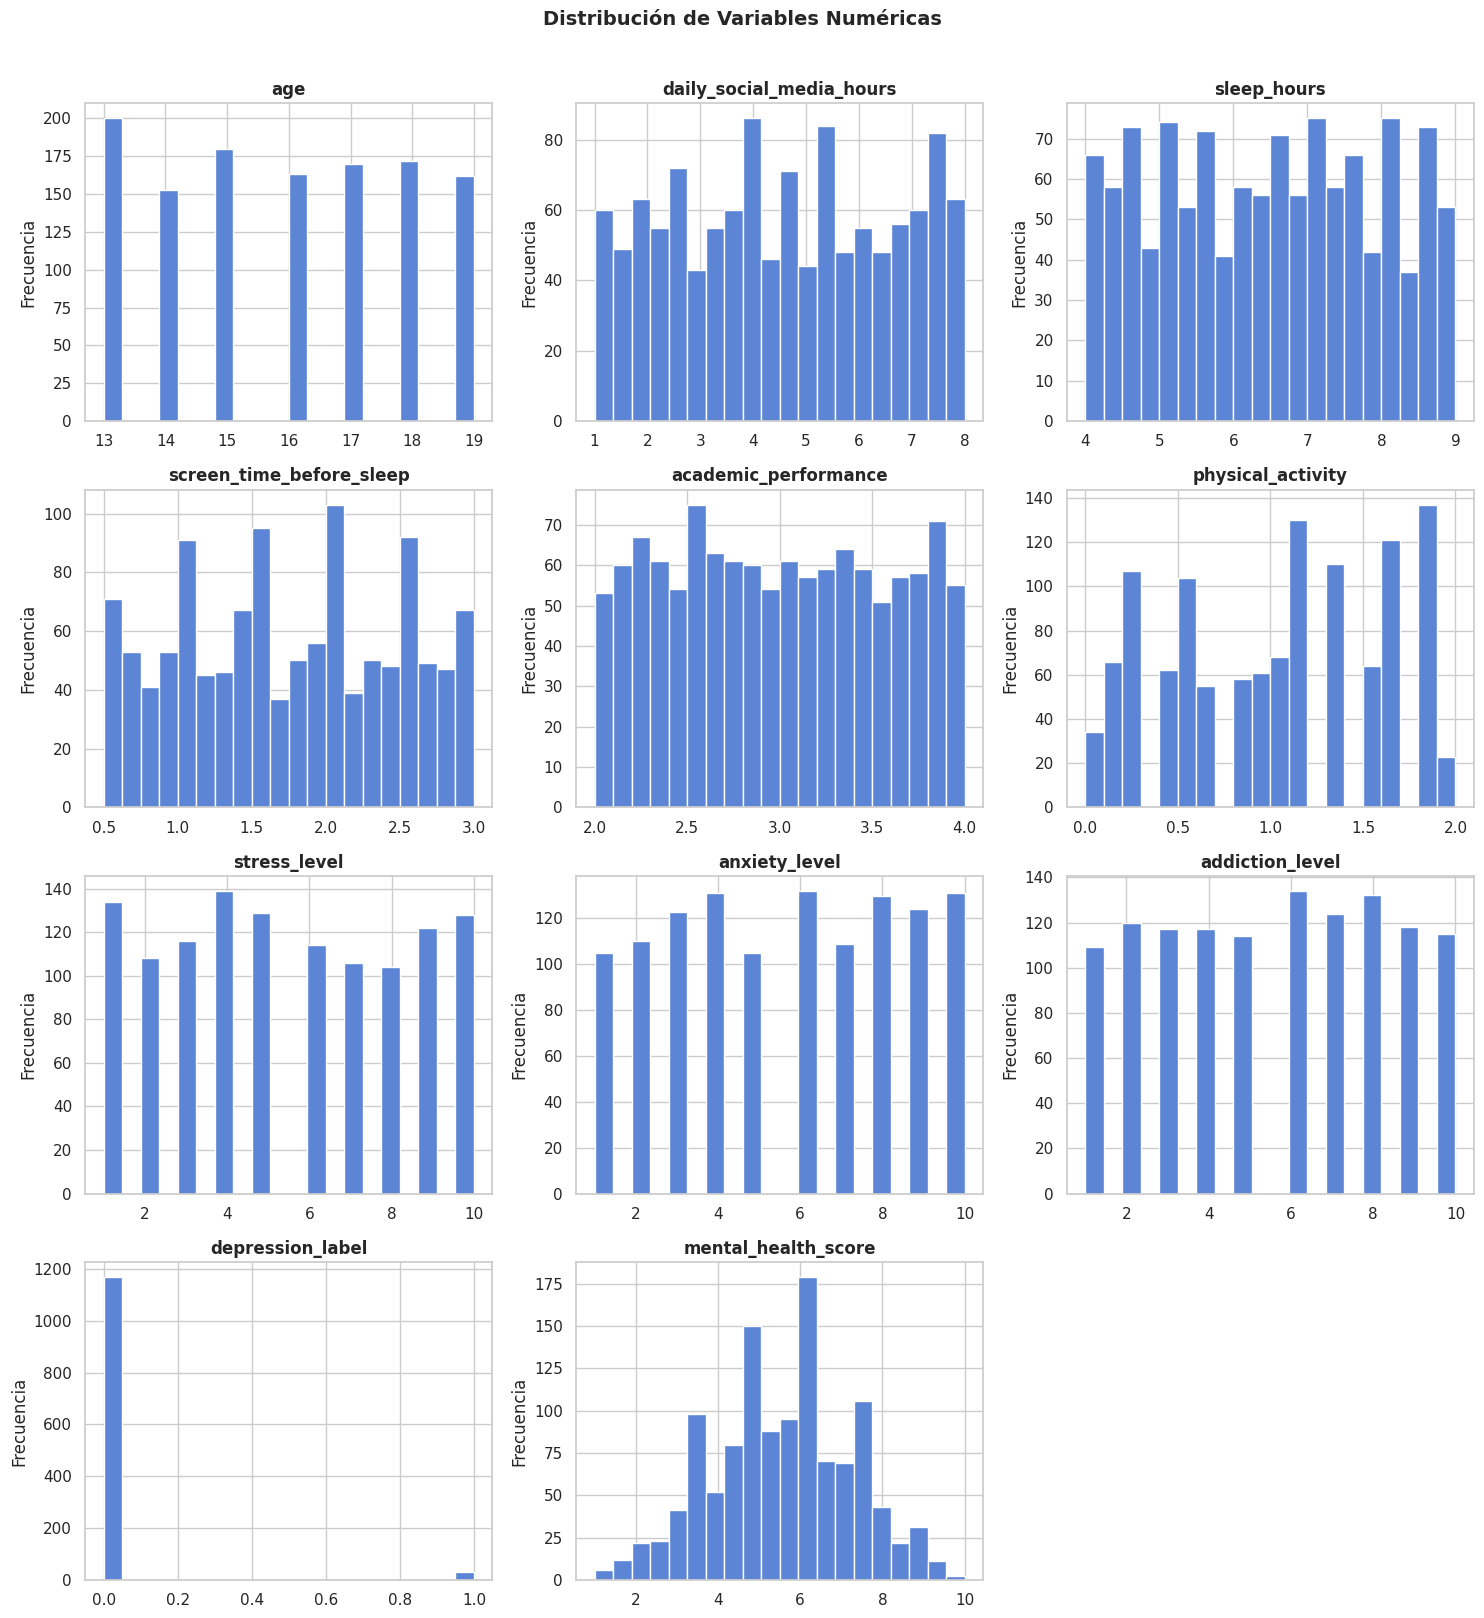

✅ Gráfica guardada


In [34]:
# Gráfica 2: Distribución de variables numéricas
numericas = df.select_dtypes(include='number').columns.tolist()
print(f'Variables numéricas encontradas: {numericas}')

if len(numericas) > 0:
    n = len(numericas)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(numericas):
        df[col].hist(ax=axes[i], bins=20, color='#5C85D6', edgecolor='white')
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_ylabel('Frecuencia')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('grafica_numericas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Gráfica guardada')

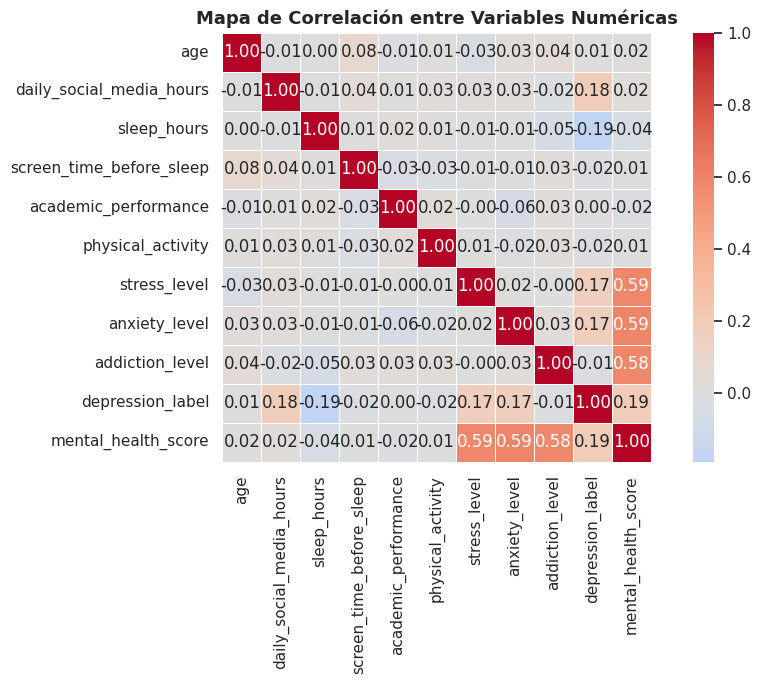

✅ Gráfica guardada


In [35]:
# Gráfica 3: Correlación entre variables numéricas
if len(numericas) > 1:
    plt.figure(figsize=(10, 7))
    corr_matrix = df[numericas].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5)
    plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafica_correlacion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Gráfica guardada')

Variables categóricas: ['gender', 'platform_usage', 'social_interaction_level']


<Figure size 1000x500 with 0 Axes>

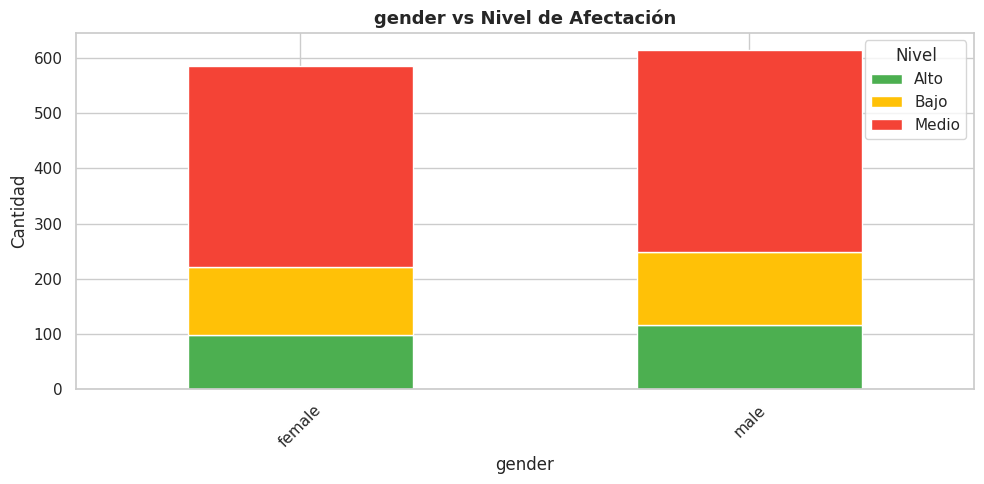

✅ Gráfica guardada


In [36]:
# Gráfica 4: Variables categóricas vs Target
categoricas = df.select_dtypes(include='object').columns.tolist()
if TARGET_COLUMN in categoricas:
    categoricas.remove(TARGET_COLUMN)

print(f'Variables categóricas: {categoricas}')

if len(categoricas) > 0:
    col_cat = categoricas[0]  # Toma la primera categórica
    plt.figure(figsize=(10, 5))
    ct = pd.crosstab(df[col_cat], df[TARGET_COLUMN])
    ct.plot(kind='bar', stacked=True, color=['#4CAF50','#FFC107','#F44336'], edgecolor='white')
    plt.title(f'{col_cat} vs Nivel de Afectación', fontsize=13, fontweight='bold')
    plt.xlabel(col_cat)
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45)
    plt.legend(title='Nivel')
    plt.tight_layout()
    plt.savefig('grafica_categorica_target.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Gráfica guardada')

## 7. Preparación de Datos para el Modelo

In [37]:
df_modelo = df.copy()

# Codificar variables categóricas a números
le = LabelEncoder()
for col in df_modelo.select_dtypes(include='object').columns:
    df_modelo[col] = le.fit_transform(df_modelo[col].astype(str))
    print(f'✅ Codificada: {col}')

print(f'\n📊 Dataset listo para el modelo: {df_modelo.shape}')
df_modelo.head()

✅ Codificada: gender
✅ Codificada: platform_usage
✅ Codificada: social_interaction_level
✅ Codificada: mental_health_risk

📊 Dataset listo para el modelo: (1200, 15)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_score,mental_health_risk
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0,1.666667,1
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0,6.333333,2
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0,2.666667,1
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0,5.666667,2
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0,3.333333,1


In [38]:
# Separar features (X) y variable objetivo (y)
# Eliminar SOLO las columnas que componen directamente el target
leakage_cols = ['stress_level', 'anxiety_level', 'addiction_level', 'mental_health_score']

X = df_modelo.drop(columns=[TARGET_COLUMN] + leakage_cols)
y = df_modelo[TARGET_COLUMN]

# Feature engineering: crear variables derivadas
X['social_media_sleep_ratio'] = X['daily_social_media_hours'] / (X['sleep_hours'] + 0.1)
X['total_screen_time'] = X['daily_social_media_hours'] + X['screen_time_before_sleep']
X['activity_sleep_ratio'] = X['physical_activity'] / (X['sleep_hours'] + 0.1)

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train: {X_train.shape[0]} muestras')
print(f'✅ Test:  {X_test.shape[0]} muestras')
print(f'✅ Features ({X.shape[1]}): {list(X.columns)}')
print(f'\n⚠️  Columnas eliminadas por leakage: {leakage_cols}')

✅ Train: 960 muestras
✅ Test:  240 muestras
✅ Features (13): ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'depression_label', 'social_media_sleep_ratio', 'total_screen_time', 'activity_sleep_ratio']

⚠️  Columnas eliminadas por leakage: ['stress_level', 'anxiety_level', 'addiction_level', 'mental_health_score']


## 8. Entrenamiento del Modelo — Comparación de Algoritmos

In [39]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, eval_metric='mlogloss', random_state=42),
    'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'Red Neuronal (MLP)': Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=42
        ))
    ])
}

resultados = {}
for nombre, mod in modelos.items():
    cv_scores = cross_val_score(mod, X_train, y_train, cv=5, scoring='accuracy')
    mod.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, mod.predict(X_test))
    resultados[nombre] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(), 'test_acc': test_acc}
    print(f'{nombre:25s} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test: {test_acc:.4f}')

# Seleccionar el mejor modelo
mejor_nombre = max(resultados, key=lambda k: resultados[k]['test_acc'])
modelo = modelos[mejor_nombre]
print(f'\n✅ Mejor modelo: {mejor_nombre} (Test Accuracy: {resultados[mejor_nombre]["test_acc"]:.2%})')

Random Forest             | CV: 0.6021 ± 0.0085 | Test: 0.5833
Gradient Boosting         | CV: 0.5510 ± 0.0121 | Test: 0.5667
XGBoost                   | CV: 0.5385 ± 0.0053 | Test: 0.5333
SVM                       | CV: 0.3458 ± 0.0634 | Test: 0.4125
Red Neuronal (MLP)        | CV: 0.6073 ± 0.0112 | Test: 0.6000

✅ Mejor modelo: Red Neuronal (MLP) (Test Accuracy: 60.00%)


## 9. Evaluación del Modelo

In [40]:
y_pred = modelo.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'🎯 Mejor modelo: {mejor_nombre}')
print(f'🎯 Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print(f'   (Baseline aleatorio para 3 clases: ~33.33%)')
print('\n=== Reporte de Clasificación ===')
print(classification_report(y_test, y_pred))

🎯 Mejor modelo: Red Neuronal (MLP)
🎯 Accuracy: 0.6000 (60.00%)
   (Baseline aleatorio para 3 clases: ~33.33%)

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.25      0.02      0.04        43
           1       0.00      0.00      0.00        51
           2       0.61      0.98      0.75       146

    accuracy                           0.60       240
   macro avg       0.29      0.33      0.26       240
weighted avg       0.41      0.60      0.46       240



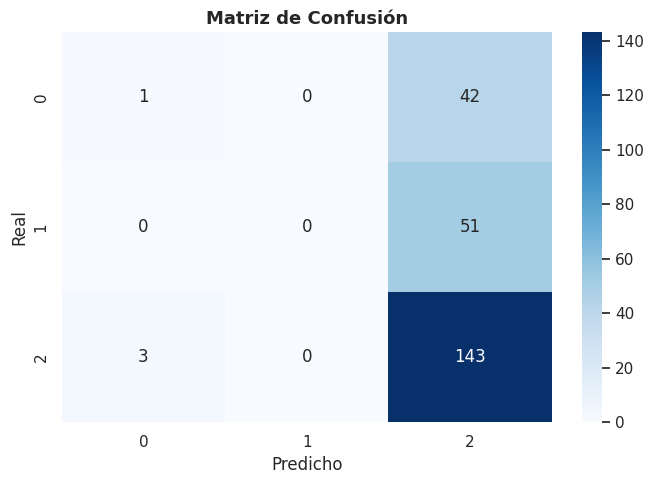

In [41]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.title('Matriz de Confusión', fontsize=13, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('grafica_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

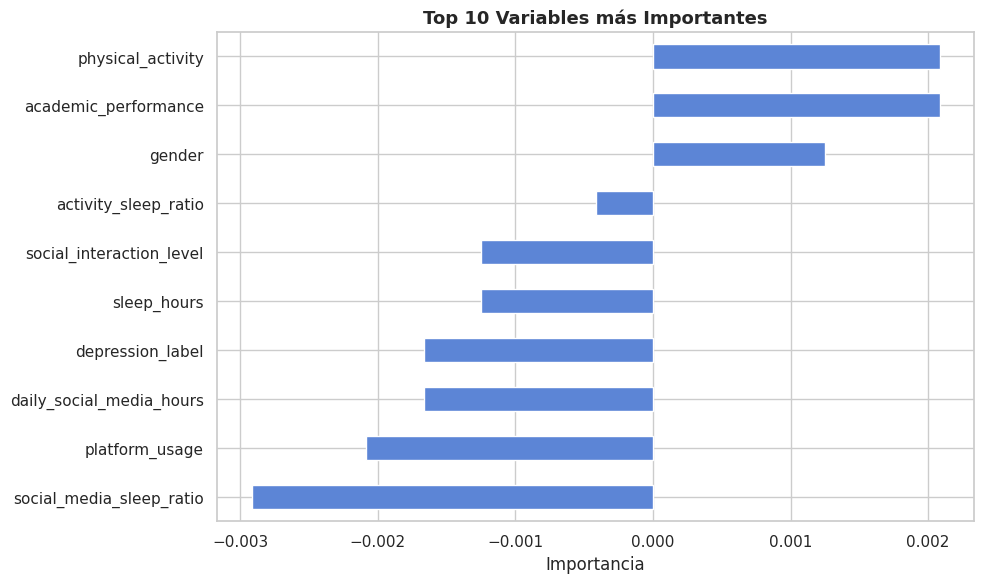

In [42]:
# Variables más importantes para la predicción
if hasattr(modelo, 'feature_importances_'):
    importancias = pd.Series(modelo.feature_importances_, index=X.columns)
else:
    # Para SVM u otros modelos sin feature_importances_, usar permutation importance
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(modelo, X_test, y_test, n_repeats=10, random_state=42)
    importancias = pd.Series(perm.importances_mean, index=X.columns)

importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.tail(10).plot(kind='barh', color='#5C85D6', edgecolor='white')
plt.title('Top 10 Variables más Importantes', fontsize=13, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('grafica_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Resumen Final

In [43]:
print('=' * 55)
print('        RESUMEN DEL PROYECTO')
print('=' * 55)
print(f'Dataset:             {df.shape[0]} registros')
print(f'Variable objetivo:   {TARGET_COLUMN} (Bajo / Medio / Alto)')
print(f'Composición target:  promedio(stress, anxiety, addiction)')
print(f'Features usadas:     {X.shape[1]} variables')
print(f'Mejor modelo:        {mejor_nombre}')
print(f'Accuracy:            {acc*100:.2f}% (baseline: 33.33%)')
print(f'Variable más importante: {importancias.idxmax()}')
print('=' * 55)
print('\nModelos comparados:')
for nombre, res in resultados.items():
    marca = ' ← MEJOR' if nombre == mejor_nombre else ''
    print(f'  {nombre:20s} | Test: {res["test_acc"]:.2%}{marca}')

        RESUMEN DEL PROYECTO
Dataset:             1200 registros
Variable objetivo:   mental_health_risk (Bajo / Medio / Alto)
Composición target:  promedio(stress, anxiety, addiction)
Features usadas:     13 variables
Mejor modelo:        Red Neuronal (MLP)
Accuracy:            60.00% (baseline: 33.33%)
Variable más importante: academic_performance

Modelos comparados:
  Random Forest        | Test: 58.33%
  Gradient Boosting    | Test: 56.67%
  XGBoost              | Test: 53.33%
  SVM                  | Test: 41.25%
  Red Neuronal (MLP)   | Test: 60.00% ← MEJOR
